<a href="https://colab.research.google.com/github/Pedro-Laynes/bioinf_2025/blob/main/CLASES/clase_5/TAREA_1_PEDRO_LAYNES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TAREA N°1 Bioinformpatica

In [40]:
# En primer lugar conectamos Google Drive
from google.colab import drive
drive.mount('/content/drive')

# coloco el nombre a la carpeta donde guardaré archivos
%cd /content/drive/MyDrive/Colab_Notebooks_tarea/


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab_Notebooks_tarea


In [41]:
# Instalo biopython para poder realizar la tarea.
!pip install biopython dna_features_viewer


In [46]:
from Bio import Entrez, SeqIO

# Coloco un correo
Entrez.email = "pedrolaynes8@gmail.com"

# Uso un código de acceso del gen COX2 de Anisakis simplex
accession = "NC_007934"

# Obtengo la secuencia en formato FASTA desde NCBI
handle = Entrez.efetch(db="nucleotide", id=accession, rettype="fasta", retmode="text")
record = SeqIO.read(handle, "fasta")
handle.close()

# Guardo la secuencia descargada en mi Google Drive con el nombre: "Anisakis_COX2"
output_path = "/content/drive/MyDrive/Colab_Notebooks_tarea/Anisakis_COX2.fasta"
SeqIO.write(record, output_path, "fasta")

print("✅ Secuencia descargada correctamente:")
print("ID:", record.id)
print("Descripción:", record.description)
print("Longitud (nucleótidos):", len(record.seq))
print("Primeros 101 nt:", record.seq[:101])



✅ Secuencia descargada correctamente:
ID: NC_007934.1
Descripción: NC_007934.1 Anisakis simplex mitochondrion, complete genome
Longitud (nucleótidos): 13916
Primeros 101 nt: TTGGTTCTTTTATTGTTGGAAGTTATTTTAGTGATGTTATTTGTTGTTCAGGCTATTGCTTTTGTTACTTTGTACGAGCGTCATTTGCTGGGTGGTAGTCA


In [52]:
from Bio.Seq import Seq

# Leo la secuencia desde el archivo FASTA guardado
registro = SeqIO.read(output_path, "fasta")

# Convierto la secuencia a lista para poder editar
seq_list = list(str(registro.seq))

# Simulo una mutación cambiando un nucleótido en la posición 1200
seq_list[1200] = "X"

# Reconstruimos la secuencia mutada
secuencia_mutada = Seq("".join(seq_list))

# Ubico la secuencia mutada en el centro de un fragmento de nucleotidos
print("🔬 Fragmento de la secuencia mutada (posiciones 1190–1210):")
print(secuencia_mutada[1190:1210])


🔬 Fragmento de la secuencia mutada (posiciones 1190–1210):
GTGAAAAGTTXTCTATTTAT


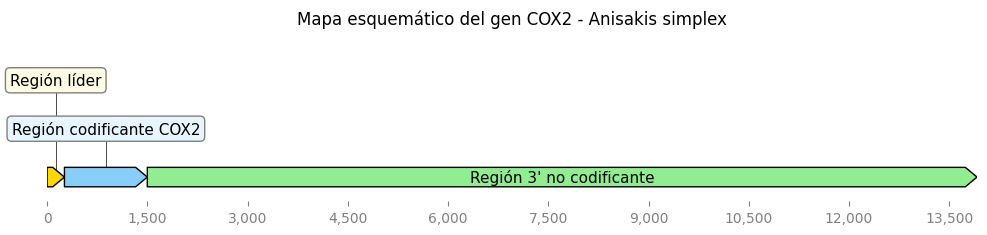

In [60]:
from dna_features_viewer import GraphicFeature, GraphicRecord
import matplotlib.pyplot as plt

# Creamos anotaciones representando regiones hipotéticas del gen COX2
features = [
    GraphicFeature(start=0, end=260, strand=+1, color="#FFD700", label="Región líder"),
    GraphicFeature(start=260, end=1500, strand=+1, color="#87CEFA", label="Región codificante COX2"),
    GraphicFeature(start=1500, end=len(secuencia_mutada), strand=+1, color="#90EE90", label="Región 3' no codificante")
]

# Creamos el gráfico
record_vis = GraphicRecord(sequence_length=len(secuencia_mutada), features=features)
ax, _ = record_vis.plot(figure_width=12)
plt.title("Mapa esquemático del gen COX2 - Anisakis simplex")
plt.show()

#aqui puedo ver que la mutación ha caido en la region codificante "posicion 1200"

In [39]:
mutated_output = "/content/drive/MyDrive/Colab_Notebooks_tarea/Anisakis_COX2_mutado.fasta"
SeqIO.write(SeqIO.SeqRecord(secuencia_mutada, id="Anisakis_COX2_mutado", description="Mutación simulada en pos.1200"), mutated_output, "fasta")
print("✅ Secuencia mutada guardada como:", mutated_output)


✅ Secuencia mutada guardada como: /content/drive/MyDrive/Colab_Notebooks_tarea/Anisakis_COX2_mutado.fasta
